In [ ]:
# pandas pour manipuler les données en tableaux
import pandas as pd
# matplotlib pour créer des graphiques
import matplotlib.pyplot as plt
# librairie de visualisation + belle que matplotlib
import seaborn as sns
# pour se connecter à la base de données SQLite
from sqlalchemy import create_engine

# crée une connexion vers la base de données SQLite (pour faire des requêtes)
engine = create_engine('sqlite:///../data/exoplanets.db')
# charge le fichier csv dans un DataFrame pandas
df = pd.read_csv('../data/exoplanets_clean.csv')

print(f"Ready ! {len(df)} planets loaded.")

Ready ! 6128 planets loaded.


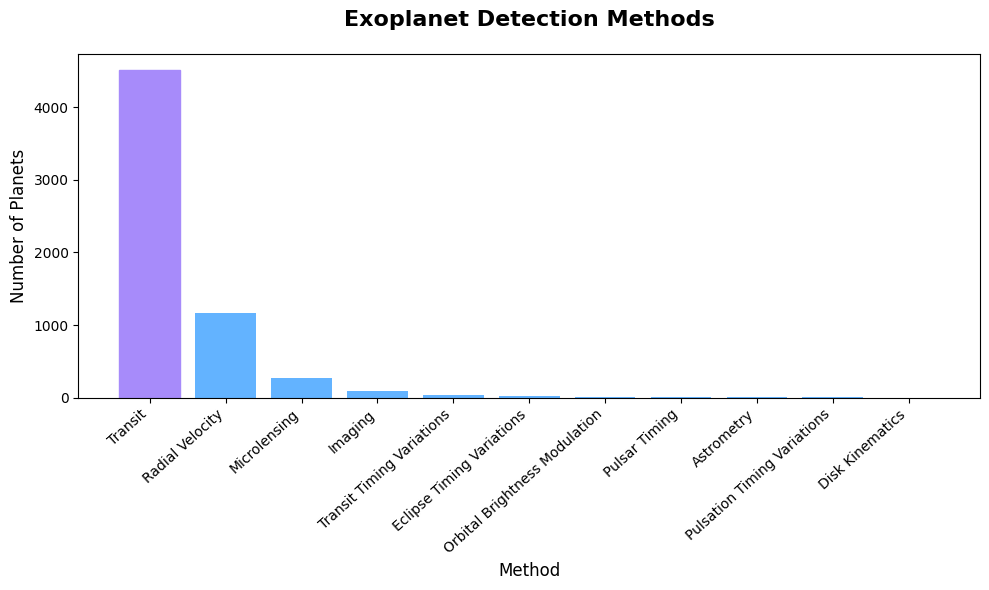

Chart saved!


In [ ]:
# Bar chart : Detection methods

# compte le nb de planètes par méthode de détection et trie automatiquement du + grand au + petit (équivalent de lq requête SQL)
detection = df['discoverymethod'].value_counts()

# crée une figure de taille 10x6 pouces
plt.figure(figsize=(10, 6))

# crée le bar chart (noms ds méthodes sur X, nb de planètes sur Y, barres en bleu, pas de bordure sur les barres)
bars = plt.bar(detection.index, detection.values, color='#63b3ff', edgecolor='none')

# colore la 1ere barre en violet pour la mettre en valeur
bars[0].set_color('#a78bfa')

plt.title('Exoplanet Detection Methods', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Method', fontsize=12)
plt.ylabel('Number of Planets', fontsize=12)
# pivote les labels X à 42 degrés pour qu'ils ne se chevauchent pas
plt.xticks(rotation=42, ha='right')
# qjuste automatiquement les marges pour que rien ne soit coupé
plt.tight_layout()
# sauvegarde le graphique en PNG dans le dossier dashboard avec une résolution de 150 dpi et sans marges blanches
plt.savefig('../dashboard/detection_methods.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

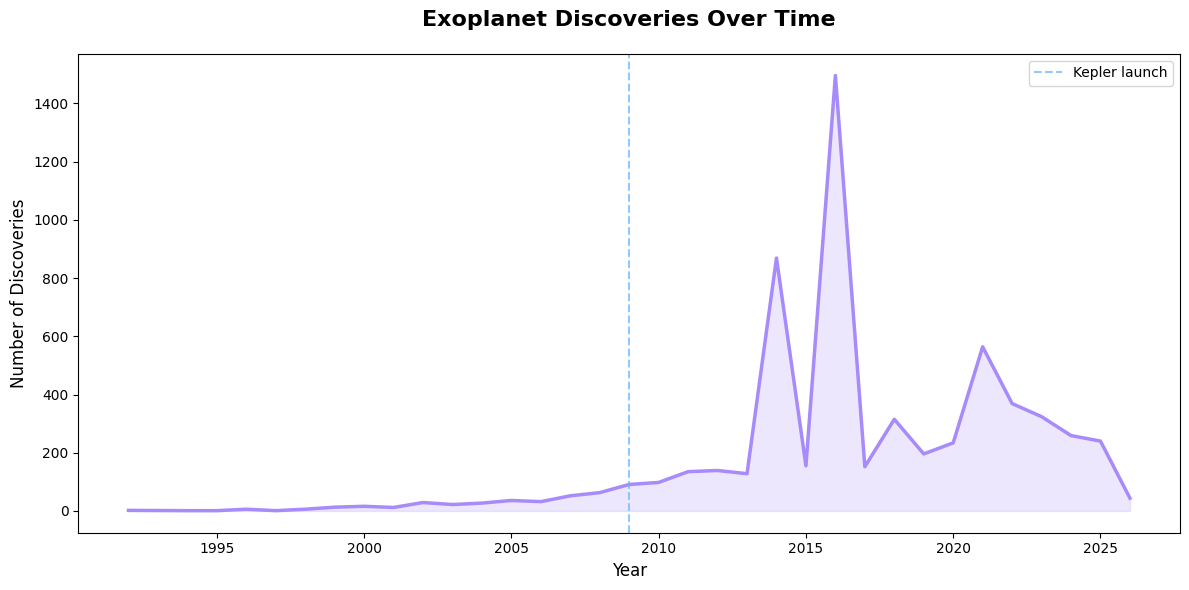

Chart saved!


In [ ]:
# Line chart : Discoveries over time

# prépare les données : regroupe les planètes par année, compte le nb de planètes par groupe, transforme le résulttat en df avec une colonne count
discoveries = df.groupby('disc_year').size().reset_index(name='count')

plt.figure(figsize=(12, 6))
# trace la ligne
plt.plot(discoveries['disc_year'], discoveries['count'], color='#a78bfa', linewidth=2.5)
# remplit la zone sous la courbe avec une transparence de 20%
plt.fill_between(discoveries['disc_year'], discoveries['count'], alpha=0.2, color='#a78bfa')

plt.title('Exoplanet Discoveries Over Time', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Discoveries', fontsize=12)
# trace une ligne verticale à l'année 2009 pour marquer le lancement de Kepler
plt.axvline(x=2009, color='#63b3ff', linestyle='--', alpha=0.7, label='Kepler launch')
# affiche la légende qui explique la ligne pointillée bleue
plt.legend()
plt.tight_layout()
plt.savefig('../dashboard/discoveries_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")


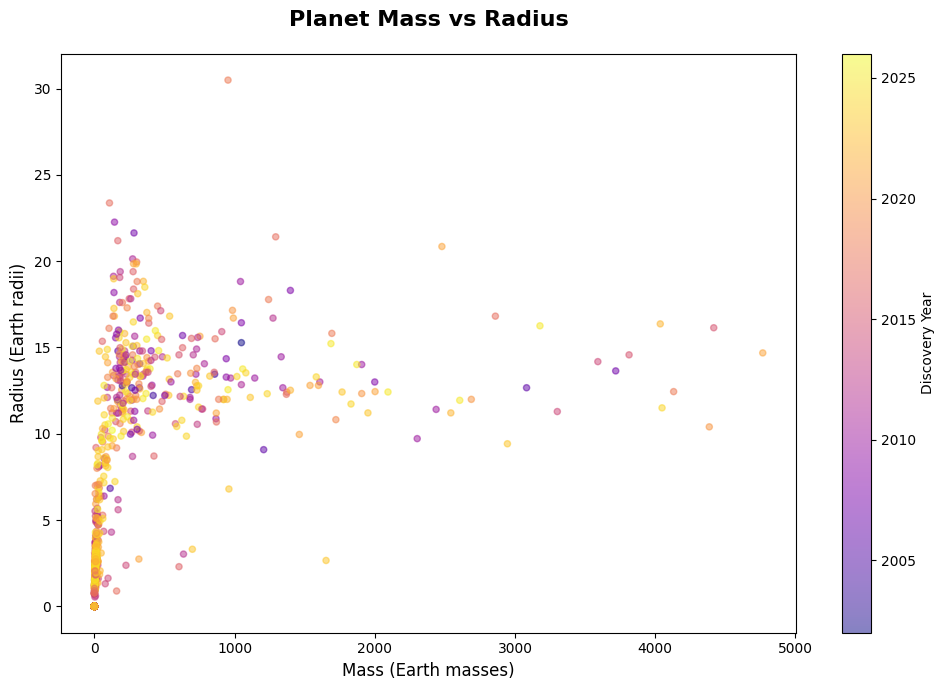

Chart saved!


In [4]:
# Scatter plot : masse vs radius

# on supprime les lignes ou la masse OU le rayon est manquant
df_clean = df.dropna(subset=['pl_bmasse', 'pl_rade'])

# on filtre les planètes avec une masse < 5000 masses terrestres
# pour éviter que Kepler-1999 b écrase tout le graphique
df_clean = df_clean[df_clean['pl_bmasse'] < 5000]

# Meme chose
df_clean = df_clean[df_clean['pl_rade'] < 50]

# on crée une figura de taille 10x7 pouces
plt.figure(figsize=(10, 7))

# on crée le scatter plot :
# axe X = masse des planètes
# axe Y = rayon des planètes
# c = couleur selon l'année de découverte (disc_year)
# cmap='plasma' = palette de couleur jaune/violet
# alpha=0.5 = transparence à 50% pour voir les superpositions
# s=20 = taille des points
scatter = plt.scatter(df_clean['pl_bmasse'], df_clean['pl_rade'],
                      c=df_clean['disc_year'], cmap='plasma', 
                      alpha=0.5, s=20)

# on ajoute une barre de couleur sur le côté pour lire l'année
plt.colorbar(scatter, label='Discovery Year')

plt.title('Planet Mass vs Radius', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mass (Earth masses)', fontsize=12)
plt.ylabel('Radius (Earth radii)', fontsize=12)
plt.tight_layout()

# on sauvegarde le graphique dans le dossier dashboard
plt.savefig('../dashboard/mass_vs_radius.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")


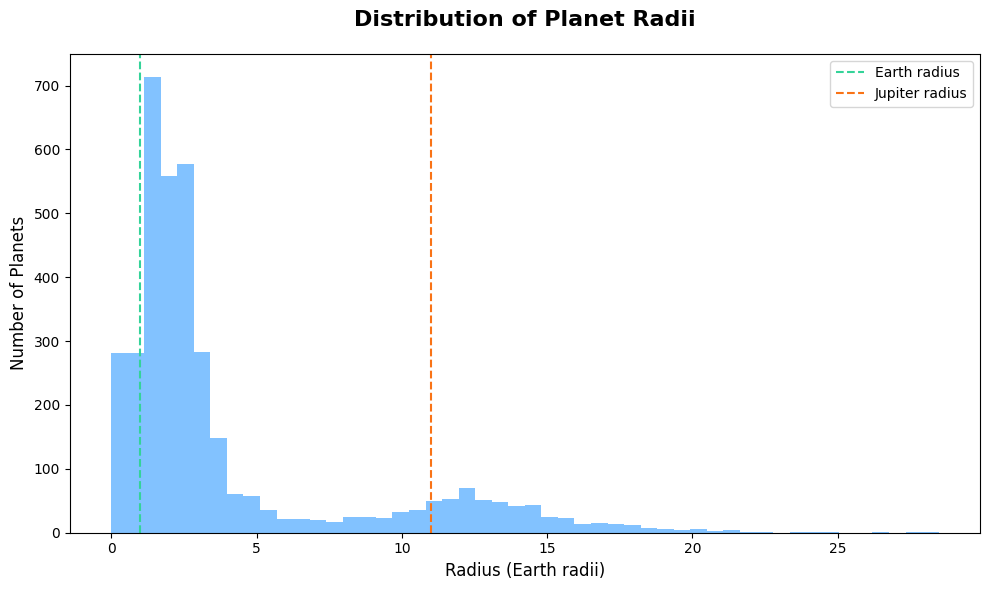

Chart saved!


In [ ]:
# Histogram : Distribution of planet radii
df_rad = df[df['pl_rade'] < 30].dropna(subset=['pl_rade'])

plt.figure(figsize=(10, 6))
plt.hist(df_rad['pl_rade'], bins=50, color='#63b3ff', edgecolor='none', alpha=0.8)

plt.title('Distribution of Planet Radii', fontsize=16,fontweight='bold', pad=20)
plt.xlabel('Radius (Earth radii)', fontsize=12)
plt.ylabel('Number of Planets', fontsize=12)
plt.axvline(x=1, color="#34d399", linestyle='--', label='Earth radius')
plt.axvline(x=11, color='#f97316', linestyle='--', label='Jupiter radius')
plt.legend()
plt.tight_layout()
plt.savefig('../dashboard/radius_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

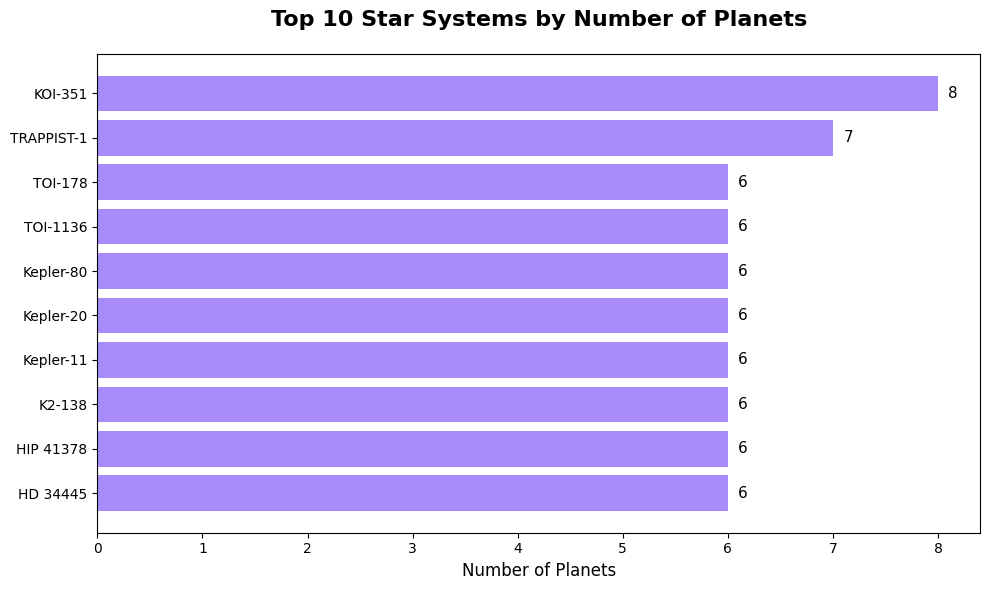

Chart saved!


In [ ]:
# Bar chart horizontal : Top 10 star systems by number of planets

# df -> vient du CSV -> pas besoin de requête SQL
# exoplanets_systems -> existe uniquement dans SQLite -> requête SQL obligatoire

query = """
SELECT hostname, COUNT(*) as nb_planets
FROM exoplanets_systems
GROUP BY hostname
HAVING nb_planets > 3
ORDER BY nb_planets DESC
LIMIT 10
"""
top_systems = pd.read_sql(query, engine)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_systems['hostname'], top_systems['nb_planets'], 
                color='#a78bfa', edgecolor='none')

for bar, val in zip(bars, top_systems['nb_planets']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=11)

plt.title('Top 10 Star Systems by Number of Planets', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Planets', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../dashboard/top_systems.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")